# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
! pip install tensorflow.keras

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Data Cleaning

In [4]:
df = pd.read_csv('Train.csv')

In [5]:
df.sample(10)

,ID,Longitude,Latitude,start_date,end_date,horizon_lower,horizon_upper,Depth_cm,Al,B,...,Fe,Mg,Mn,N,ph,P,K,Na,S,Zn
5131,GUWRLX,-0.73948,5.39506,01/01/2008,31/12/2018,50,20,20-50,795.379,NaN,...,133.698,799.5870,173.7610,0.890,7.1700,NaN,294.1420,NaN,NaN,NaN
25585,J4QJNW,33.00415,-8.58587,01/01/2008,31/12/2018,50,20,20-50,885.769,NaN,...,187.256,694.6520,101.3680,0.510,7.2140,NaN,736.7940,NaN,NaN,NaN
15846,R9DGCL,-1.64531,7.50224,01/01/2008,31/12/2018,20,0,0-20,786.855,NaN,...,83.970,175.3550,143.1180,0.590,6.6260,NaN,107.8970,NaN,NaN,NaN
19749,628YUT,34.72533,-4.42643,01/01/2008,31/12/2018,20,0,0-20,631.513,NaN,...,89.196,310.1405,173.2685,0.965,6.6065,NaN,297.1195,NaN,NaN,NaN
15523,B1ECAS,-2.76615,7.27600,01/01/2008,31/12/2018,20,0,0-20,848.101,NaN,...,89.658,251.8910,246.3510,1.390,6.2480,NaN,118.5230,NaN,NaN,NaN
41304,SL86KW,34.17730,-2.02539,01/01/2008,31/12/2018,20,0,0-20,609.695,NaN,...,154.948,456.3560,146.9060,0.980,6.6880,NaN,373.5520,NaN,NaN,NaN
29385,7T4SIE,32.57958,-2.67990,01/01/2008,31/12/2018,50,20,20-50,815.332,NaN,...,202.057,228.5400,158.2180,0.810,5.1530,NaN,149.7910,NaN,NaN,NaN
7027,XZH4O3,-13.37978,10.54375,01/01/2008,31/12/2018,50,20,20-50,1360.983,NaN,...,89.832,166.0320,20.8820,3.040,6.0010,NaN,53.7740,NaN,NaN,NaN
5487,5BPLG8,4.64471,6.76200,01/01/2008,31/12/2018,50,20,20-50,1247.407,NaN,...,129.859,100.8050,78.9840,1.070,5.0430,NaN,89.4630,NaN,NaN,NaN
41633,PS9ABL,34.40119,-1.33870,01/01/2008,31/12/2018,20,0,0-20,812.609,NaN,...,113.010,572.6890,223.9600,1.550,6.8160,NaN,404.7180,NaN,NaN,NaN


In [6]:
df.shape

(44298, 25)

In [7]:
df.isnull().sum()

,0
ID,0
Longitude,0
Latitude,0
start_date,0
end_date,0
horizon_lower,0
horizon_upper,0
Depth_cm,0
Al,2
B,42389


In [8]:
sparse_columns = ['P', 'Zn', 'B', 'Na', 'S', 'electrical_conductivity','start_date', 'end_date','ID']
df = df.drop(columns=sparse_columns)
df = df.dropna() #removing negligible number of missing value rows

# Feature Enginnering

In [9]:

# 1. C:N Ratio (Biological Health)
# A ratio between 10 and 24 is ideal. Too high means microbes steal nutrients; too low means nitrogen pollutes the air.

df['C_N_Ratio'] = df['C_organic'] / (df['N'] )


In [10]:
# 2. Toxicity Index (Aluminum Risk)
#Aluminum only becomes toxic to plants when pH drops. This column creates a single number representing the danger of root burn.
df['Toxicity_Index'] = df['Al'] / (df['ph'])

In [11]:
# 3. Base Saturation Proxy (Fertility Score)
# Ratio of "Good" nutrients (Ca, Mg, K) to total major cations including metals (Al, Fe)
good_cations = df['Ca'] + df['Mg'] + df['K']
all_cations = good_cations + df['Al'] + df['Fe']
df['Base_Saturation_Proxy'] = good_cations / (all_cations)

In [12]:
# 4. Average Depth
df['Average_Depth'] = (df['horizon_lower'] + df['horizon_upper']) / 2.0

In [13]:
df[['C_N_Ratio', 'Toxicity_Index', 'Base_Saturation_Proxy', 'Average_Depth']].sample(5)

,C_N_Ratio,Toxicity_Index,Base_Saturation_Proxy,Average_Depth
23425,15.735484,271.562455,0.399541,35.0
18019,10.501916,203.648920,0.548445,10.0
18547,11.718750,161.345609,0.471037,10.0
32957,11.931818,94.432271,0.522452,10.0
11012,11.885417,81.168259,0.828272,10.0


# Clustering

In [14]:
cluster_features = ['C_N_Ratio', 'Toxicity_Index', 'Base_Saturation_Proxy', 'ph']
X_cluster = df[cluster_features]

In [15]:
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

In [16]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Agro_Zone'] = kmeans.fit_predict(X_cluster_scaled)

In [17]:
# Convert zone numbers to strings for categorical plotting
df['Agro_Zone'] = df['Agro_Zone'].astype(str)

In [27]:
zone_summary = df.groupby('Agro_Zone')[cluster_features].mean()
zone_summary

,C_N_Ratio,Toxicity_Index,Base_Saturation_Proxy,ph
Agro_Zone,,,,
0,13.591920,232.684020,0.389418,5.441706
1,11.830236,122.763856,0.646397,6.337207
2,16.912220,100.419518,0.572870,6.227250
3,13.714894,76.050812,0.886234,7.924133


# zone visualization

In [23]:

df_sample = df.sample(40000, random_state=42)

fig = px.scatter_mapbox(
    df_sample,
    lat="Latitude",
    lon="Longitude",
    color="Agro_Zone",
    hover_data=['ph', 'Base_Saturation_Proxy', 'C_N_Ratio','Toxicity_Index'],
    color_discrete_sequence=px.colors.qualitative.G10,
    zoom=4,
    height=600,
    title="Map of Agro-Ecological Zones (Macro Insight)"
)

fig.update_layout(mapbox_style="carto-positron")
fig.show()

# Organic Carbon Prediction

In [29]:
dl_features = ['Latitude', 'Longitude', 'Average_Depth', 'Toxicity_Index', 'Base_Saturation_Proxy', 'ph', 'N']
X = df[dl_features]
y = df['C_organic']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


dl_scaler = StandardScaler()
X_train_scaled = dl_scaler.fit_transform(X_train)
X_test_scaled = dl_scaler.transform(X_test)


model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])


model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,393 (44.50 KB)

 Trainable params: 11,393 (44.50 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:

print("Training the 3D Carbon Forecaster...")
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    verbose=1
)


predictions = model.predict(X_test_scaled)
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print(f"\n Model Evaluation:")
print(f"R-Squared (Accuracy): {r2:.3f}")
print(f"Mean Absolute Error: {mae:.3f} (On average, we are off by {mae:.3f} units of C_organic)")

Training the 3D Carbon Forecaster...
Epoch 1/30
424/424 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 74.4394 - mae: 5.2850 - val_loss: 6.8038 - val_mae: 1.6597
Epoch 2/30
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.3706 - mae: 2.0447 - val_loss: 5.7000 - val_mae: 1.5256
Epoch 3/30
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.8545 - mae: 1.9279 - val_loss: 5.3454 - val_mae: 1.4930
Epoch 4/30
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.6489 - mae: 1.8439 - val_loss: 5.1439 - val_mae: 1.4548
Epoch 5/30
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 8.3262 - mae: 1.8688 - val_loss: 5.0974 - val_mae: 1.4560
Epoch 6/30
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.3336 - mae: 1.8050 - val_loss: 4.8714 - val_mae: 1.4269
Epoch 7/30
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.7259 - mae: 1.7515 - val_loss: 6.1762 - val_mae: 1.7436
Epoch 8/30
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.7930 - mae: 1.7415 - val_loss: 4.5887 - val_mae: 1.3968
Epoch 9/30
424/424

val cross plot

Simulating Carbon Levels at Lat: -9.05, Lon: 34.61
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



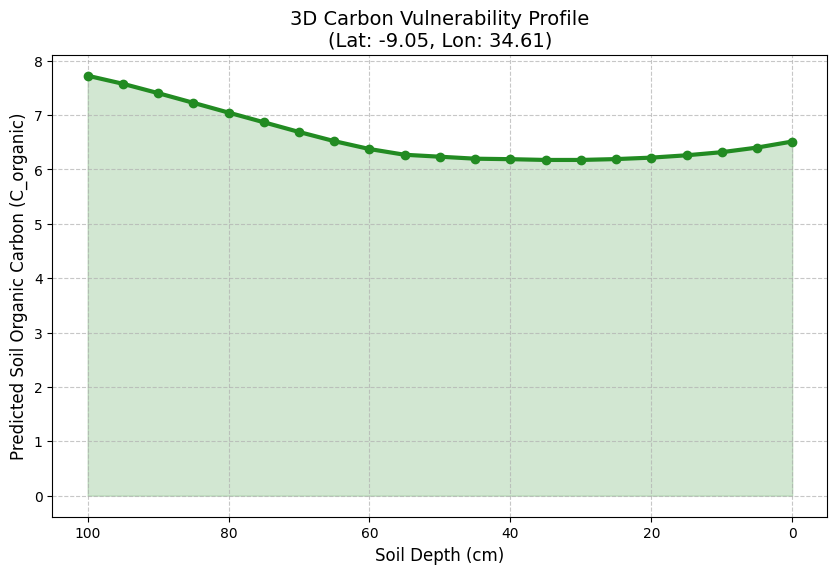

Insight: Notice how rapidly Carbon depletes as you dig deeper. This proves the importance of protecting the topsoil from erosion!


In [31]:

sample_location = X_test.iloc[0].copy()
actual_lat = sample_location['Latitude']
actual_lon = sample_location['Longitude']

print(f"Simulating Carbon Levels at Lat: {actual_lat:.2f}, Lon: {actual_lon:.2f}")


depths_to_simulate = np.arange(0, 101, 5)
simulated_data = []

for depth in depths_to_simulate:
    scenario = sample_location.copy()
    scenario['Average_Depth'] = depth
    simulated_data.append(scenario.values)


simulated_data_scaled = dl_scaler.transform(simulated_data)
predicted_carbon = model.predict(simulated_data_scaled).flatten()


plt.figure(figsize=(10, 6))
plt.plot(depths_to_simulate, predicted_carbon, marker='o', color='forestgreen', linewidth=3)
plt.title(f"3D Carbon Vulnerability Profile\n(Lat: {actual_lat:.2f}, Lon: {actual_lon:.2f})", fontsize=14)
plt.xlabel("Soil Depth (cm)", fontsize=12)
plt.ylabel("Predicted Soil Organic Carbon (C_organic)", fontsize=12)
plt.gca().invert_xaxis()
plt.grid(True, linestyle='--', alpha=0.7)
plt.fill_between(depths_to_simulate, predicted_carbon, color='forestgreen', alpha=0.2)
plt.show()

print("Insight: Notice how rapidly Carbon depletes as you dig deeper. This proves the importance of protecting the topsoil from erosion!")